# Vv-Gamma チャート作成例

`VVGammaChart.py` の薄い使用例です。主計算はモジュール側に置き、notebook は条件設定・実行・可視化だけにします。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import sys
import os

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../../../')) # 親ディレクトリをモジュール探索パスに追加
from src.VvGammaChart import (
    calculate_vv_gamma_metrics_from_stab,
    plot_vv_gamma_contour,
    run_vv_gamma_chart,
)

## 1. 既存 `.stab` の読み取り確認

OpenVSP が使えない環境でも、`.stab` の後処理だけは確認できます。

In [2]:
metrics = calculate_vv_gamma_metrics_from_stab(
    '../../models/BRGlider/BRGlider.stab',
    vv=np.nan,
    tip_deflection=np.nan,
)
pd.Series(metrics)[[
    'Gamma_eff_deg',
    'CL_alpha',
    'Cl_beta',
    'Cn_beta',
    'Cl_delta_r',
    'Cn_delta_r',
    'spiral_margin',
    'control_column_delta_r',
]]

Gamma_eff_deg             5.287216
CL_alpha                  5.983843
Cl_beta                  -0.117177
Cn_beta                  -0.003417
Cl_delta_r                0.002638
Cn_delta_r               -0.007557
spiral_margin             0.001936
control_column_delta_r    ConGrp_3
dtype: object

## 2. Vv-Gamma sweep の条件

以下は OpenVSP Python API が使える環境で実行します。`turn_trim_mode` は `none`, `level`, `gliding` から選べます。

In [9]:
base_vsp3_path = Path('../../models/BRGlider/BRGlider.0G.vsp3')
output_dir = Path('vv_gamma_cases')

vv_values = np.linspace(0.001, 0.006, 6) - 0.0005
tip_deflections = np.linspace(0.0, 1.5, 7) + 0.125

flight_condition = {
    'alpha_deg': 0.0,
    'mach': 0.0,
    'reynolds': 1.0e6,
}

geometry_config = {
    'lv': 4.5,          # x_ac_vtail - xcg, model length unit
    'wing_area': 18,
    'wing_span': 27,
    'xcg': 1.4,
    'wing_name': 'WingGeom',
    'vtail_name': 'VTailGeom',
    'n_span': 101,
    "vtail_area_scale_mode": "fixed_aspect_ratio",
}

In [10]:
print(vv_values)
print(tip_deflections)

[0.0005 0.0015 0.0025 0.0035 0.0045 0.0055]
[0.125 0.375 0.625 0.875 1.125 1.375 1.625]


In [11]:
results = run_vv_gamma_chart(
    base_vsp3_path,
    vv_values,
    tip_deflections,
    flight_condition,
    geometry_config,
    output_dir,
    turn_trim_mode='none',
    validate_base_model=True,
    fixed_wake_flag=False,
    wake_num_iter=10,
    ncpu=8,
    verbose=1,
)
results.head()

[2026-07-05 05:21:04] Start Vv-Gamma chart sweep: cases=42, output_dir=vv_gamma_cases
[2026-07-05 05:21:04] Base model validation start: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\BRGlider\BRGlider.0G.vsp3

-> Validate G103A stability-derivative preflight: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\models\BRGlider\BRGlider.0G.vsp3
 Checking required Geoms...
 Checking required control-surface Subsurfaces...
 Checking ThickGeom / ThinGeom sets...
 Checking VSPAERO settings...
 Checking VSPAERO control-surface groups and gains...
 Validation PASSED: 0 error(s), 0 warning(s)
[2026-07-05 05:21:05] Base model validation passed
[2026-07-05 05:21:05] Reference wing loaded from .vsp3: source=vspaero_reference_wing, area=18, span=27
[2026-07-05 05:21:05] Case 1/42 start: Vv=0.0005, tip_deflection=0.125

-> Calculate G103A VSPAERO stability derivatives: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart.BRGlider\vv_gamma_cases\vv_0p0

,case,case_index,case_count,Vv,tip_deflection,case_dir,passed,vtail_input_vsp3_path,vtail_output_vsp3_path,vtail_vtail_name,...,Rho,Vinf,turn_trim_mode,turn_trim_passed,coupled_gain_matrix_det,coupled_gain_solved,beta_per_delta_r_coupled,p_hat_per_delta_r_coupled,r_hat_per_delta_r_coupled,elapsed_s
0,vv_0p00050_wtip_0p12500,1,42,0.0005,0.125,vv_gamma_cases\vv_0p00050_wtip_0p12500,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,vv_gamma_cases\vv_0p00050_wtip_0p12500\vv_0p00...,VTailGeom,...,1.225,10.0,none,NaN,0.000380,True,-0.286457,0.000149,-0.026613,237.929467
1,vv_0p00050_wtip_0p37500,2,42,0.0005,0.375,vv_gamma_cases\vv_0p00050_wtip_0p37500,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,vv_gamma_cases\vv_0p00050_wtip_0p37500\vv_0p00...,VTailGeom,...,1.225,10.0,none,NaN,0.000393,True,-0.277446,0.010705,-0.022278,232.442366
2,vv_0p00050_wtip_0p62500,3,42,0.0005,0.625,vv_gamma_cases\vv_0p00050_wtip_0p62500,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,vv_gamma_cases\vv_0p00050_wtip_0p62500\vv_0p00...,VTailGeom,...,1.225,10.0,none,NaN,0.000398,True,-0.274271,0.021450,-0.018903,224.140092
3,vv_0p00050_wtip_0p87500,4,42,0.0005,0.875,vv_gamma_cases\vv_0p00050_wtip_0p87500,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,vv_gamma_cases\vv_0p00050_wtip_0p87500\vv_0p00...,VTailGeom,...,1.225,10.0,none,NaN,0.000397,True,-0.275748,0.029519,-0.026306,225.490891
4,vv_0p00050_wtip_1p12500,5,42,0.0005,1.125,vv_gamma_cases\vv_0p00050_wtip_1p12500,True,C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP...,vv_gamma_cases\vv_0p00050_wtip_1p12500\vv_0p00...,VTailGeom,...,1.225,10.0,none,NaN,0.000382,True,-0.285751,0.040443,-0.027749,213.527499


## 3. 可視化

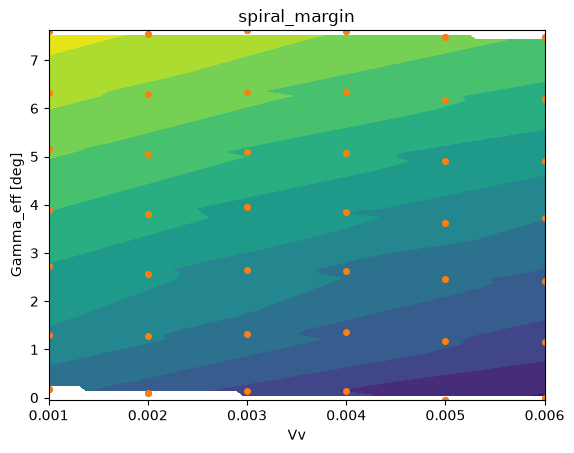

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plot_vv_gamma_contour(results, 'spiral_margin', ax=ax)
plt.show()

## 4. turn trim 指標を入れる場合

滑空旋回を評価する場合は `turn_trim_mode='gliding'` を使います。`fixed` は既存 solver の仕様に合わせて3つだけ指定します。

In [7]:
# results_with_trim = run_vv_gamma_chart(
#     base_vsp3_path,
#     vv_values,
#     tip_deflections,
#     flight_condition,
#     geometry_config,
#     output_dir / 'with_trim',
#     turn_trim_mode='gliding',
#     turn_trim_fixed={'V': 30.0, 'Omega': 0.08, 'delta_a': 0.0},
#     mass=600.0,
#     validate_base_model=True,
#     verbose=1,
# )